<a href="https://colab.research.google.com/github/alicej06/building-damage/blob/main/CAIS%2B%2B_Final_Project_Damage_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run the cell below to unzip the processed training data for the damage assessment model. Then you'll have it on the local drive, so it should be quicker to access

In [ ]:
import shutil
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define Paths
# Where the zip lives on your Google Drive
ZIP_SOURCE = "/content/drive/My Drive/CAIS++ Mini Project + Final Project/xview2/train/processed_data/processed_dataset_damage.zip"

# Where to extract it (Local Colab Disk)
EXTRACT_DEST = "/content/dataset"

# 3. Copy & Unzip (The Fast Way)
if not os.path.exists(EXTRACT_DEST):
    print("Copying zip from Drive...")
    shutil.copy(ZIP_SOURCE, "/content/temp_data.zip")

    print("Unzipping...")
    shutil.unpack_archive("/content/temp_data.zip", EXTRACT_DEST)

    # Cleanup to save space
    os.remove("/content/temp_data.zip")
    print(f"Data ready at {EXTRACT_DEST}")
else:
    print("Data already extracted!")

Mounted at /content/drive
Copying zip from Drive...
Unzipping...
Data ready at /content/dataset


# **What the Data Looks Like**

processed_dataset_damage.zip contains three parallel folders. Every file in one folder has an exact match in the others (e.g., hurricane_001_tile_0.png exists in all three). Original image is 1024x1024 (inputting into model like that is inefficient given GPU RAM)
* images_pre/:
  * Content: 512x512 RGB chips of the Pre-Disaster satellite photo.
  * Purpose: Provides the "baseline" (what the building looked like intact).
* images_post/:
  * Content: 512x512 RGB chips of the Post-Disaster satellite photo.
  * Purpose: Provides the "current state" (rubble, flood, burnt, etc.).
* masks/:
  * to be used as target
  * Content: 512x512 Grayscale chips.
  * Values:
    * 0: Background
    * 1: No Damage
    * 2: Minor Damage
    * 3: Major Damage
    * 4: Destroyed
    * 5: Unclassified (Ignore)

In [ ]:
!pip install segmentation-models-pytorch==0.3.3
!pip install albumentations==1.4.3


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 55.6 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=5fe50230a35144f598d6d923cd816bc9db6817649d484e8a92e0f7b38f322645
  Stored in directory: /root/.cache/pip/wheels/9c/3f/43/e6271c7026fe08c185da2be23c98c8e87477d3db63f41f32ad
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=d725c60a4697f875927b87ce86833905b6e75e318ed16f1c9d1a3f9904db5fd9
  Stored in directory: /root/.cache/pip/wheels/4c/01/56/40a48f75dbdfe167a0cb70d3b48913369a00ec5c4e9fed5f2b
Successfully built efficientnet-pytorc

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
import random
from torch.cuda.amp import autocast, GradScaler


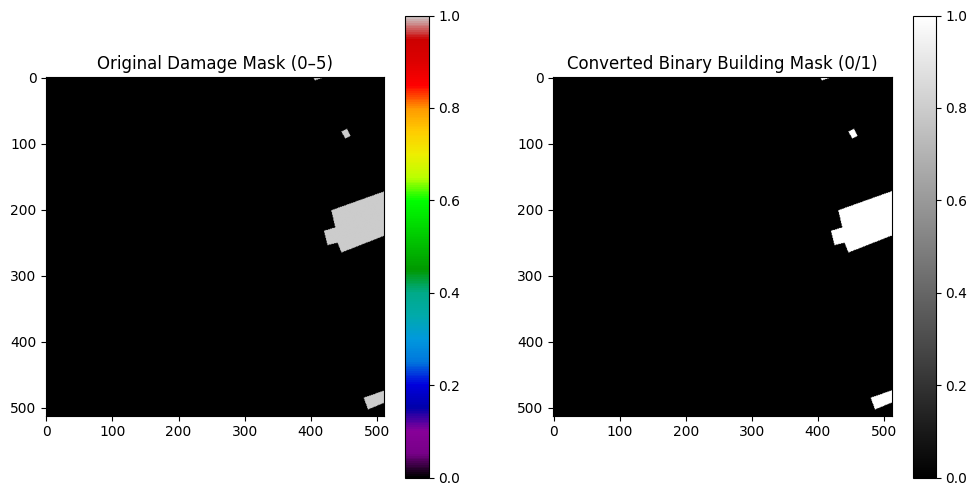

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths
DAMAGE_MASK_DIR = "/content/dataset/masks"          # original masks (0–5)
SAMPLE_NAME = sorted(os.listdir(DAMAGE_MASK_DIR))[0]  # take first file

# Load mask
path = os.path.join(DAMAGE_MASK_DIR, SAMPLE_NAME)
damage_mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Convert to binary building mask
building_mask = np.where(
    (damage_mask >= 1) & (damage_mask <= 4),
    1,      # building
    0       # background
).astype(np.uint8)

# Display
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Damage Mask (0–5)")
plt.imshow(damage_mask, cmap='nipy_spectral')
plt.colorbar()

plt.subplot(1,2,2)
plt.title("Converted Binary Building Mask (0/1)")
plt.imshow(building_mask, cmap='gray')
plt.colorbar()

plt.show()


In [ ]:
import os
import cv2
import numpy as np

MASK_DIR = "/content/dataset/masks"

unique_values = set()

for fname in os.listdir(MASK_DIR):
    mask = cv2.imread(os.path.join(MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)
    vals = np.unique(mask)
    unique_values.update(vals)

print("ALL UNIQUE PIXEL VALUES ACROSS DATASET:", unique_values)


ALL UNIQUE PIXEL VALUES ACROSS DATASET: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5)}


In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

MULTICLASS_MASK_DIR = "/content/dataset/masks"
BINARY_MASK_DIR = "/content/dataset/masks_binary"
os.makedirs(BINARY_MASK_DIR, exist_ok=True)

for fname in sorted(os.listdir(MULTICLASS_MASK_DIR)):
    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    path = os.path.join(MULTICLASS_MASK_DIR, fname)
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    # Convert to binary building footprint mask
    building_mask = np.where(
        (mask >= 1) & (mask <= 4),   # 1–4 = building
        1,                           # building = 1
        0                            # background/ignore = 0
    ).astype(np.uint8)

    # Save as 0 or 255 PNG
    out_path = os.path.join(BINARY_MASK_DIR, fname)
    Image.fromarray(building_mask * 255).save(out_path)

    print("Saved:", out_path)

print("DONE: All masks converted to binary building footprints.")


Streaming output truncated to the last 5000 lines.
Saved: /content/dataset/masks_binary/socal-fire_00000462_post_disaster_tile_5.png
Saved: /content/dataset/masks_binary/socal-fire_00000462_post_disaster_tile_6.png
Saved: /content/dataset/masks_binary/socal-fire_00000462_post_disaster_tile_7.png
Saved: /content/dataset/masks_binary/socal-fire_00000462_post_disaster_tile_8.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_0.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_1.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_2.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_3.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_4.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_5.png
Saved: /content/dataset/masks_binary/socal-fire_00000464_post_disaster_tile_6.png
Saved: /content/dataset/masks_binary/socal-fire

In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

class BuildingSegDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transforms=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.fnames = sorted(os.listdir(img_dir))
        self.transforms = transforms

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        fname = self.fnames[idx]

        img = cv2.imread(os.path.join(self.img_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.mask_dir, fname), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype("float32")  # 0/1

        if self.transforms:
            out = self.transforms(image=img, mask=mask)
            img = out["image"]
            mask = out["mask"].unsqueeze(0)

        return img.float(), mask.float()


In [ ]:
tf = A.Compose([
    A.Normalize(),
    ToTensorV2(),
])


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 421MB/s]


In [ ]:
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


In [ ]:
from torch.utils.data import DataLoader


IMG_DIR = "/content/dataset/images_pre"
MASK_DIR = "/content/dataset/masks_binary"

train_ds = BuildingSegDataset(IMG_DIR, MASK_DIR, transforms=tf)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)


NameError: name 'BuildingSegDataset' is not defined

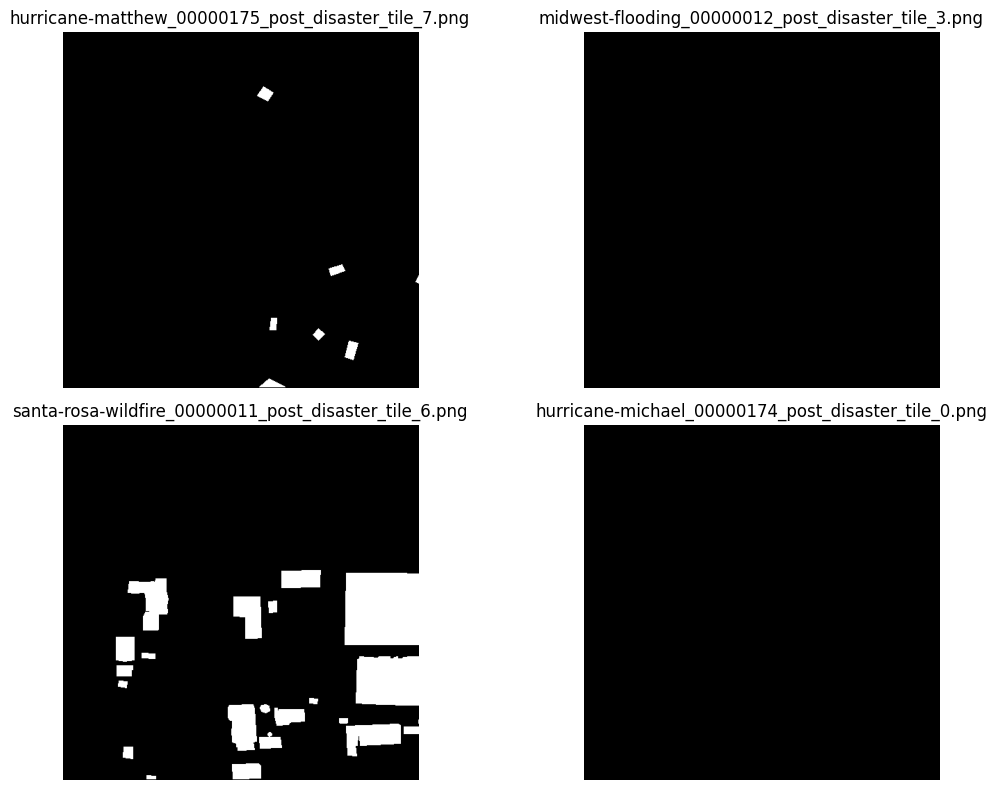

In [ ]:
import os
import random
import cv2
import matplotlib.pyplot as plt

MASK_DIR = "/content/dataset/masks_binary"

sample_files = random.sample(sorted(os.listdir(MASK_DIR)), 4)

plt.figure(figsize=(12,8))

for i, fname in enumerate(sample_files):
    mask = cv2.imread(os.path.join(MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)

    plt.subplot(2,2,i+1)
    plt.title(fname)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import os, random

FOLDER = "/content/dataset/images_pre"   # change to images_post or masks
files = sorted(os.listdir(FOLDER))

for f in random.sample(files, min(20, len(files))):
    print(f)


hurricane-michael_00000530_post_disaster_tile_7.png
hurricane-michael_00000212_post_disaster_tile_4.png
hurricane-michael_00000313_post_disaster_tile_6.png
socal-fire_00000663_post_disaster_tile_8.png
hurricane-matthew_00000009_post_disaster_tile_7.png
mexico-earthquake_00000039_post_disaster_tile_4.png
hurricane-matthew_00000048_post_disaster_tile_6.png
hurricane-harvey_00000270_post_disaster_tile_0.png
santa-rosa-wildfire_00000205_post_disaster_tile_7.png
socal-fire_00000417_post_disaster_tile_1.png
socal-fire_00000955_post_disaster_tile_8.png
hurricane-florence_00000044_post_disaster_tile_4.png
midwest-flooding_00000005_post_disaster_tile_3.png
socal-fire_00000253_post_disaster_tile_8.png
hurricane-michael_00000322_post_disaster_tile_2.png
palu-tsunami_00000108_post_disaster_tile_3.png
hurricane-harvey_00000380_post_disaster_tile_4.png
hurricane-michael_00000199_post_disaster_tile_5.png
hurricane-matthew_00000185_post_disaster_tile_0.png
hurricane-matthew_00000079_post_disaster_tile

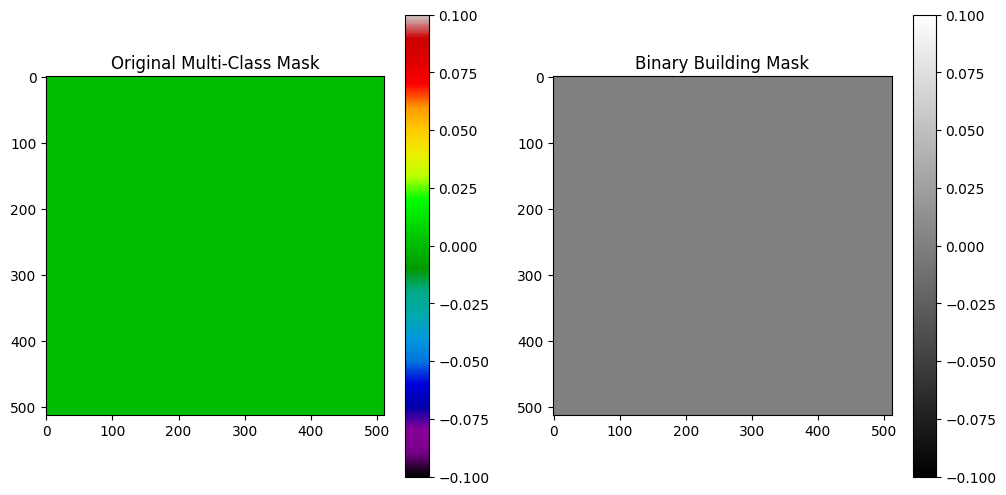

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

MULTICLASS_DIR = "/content/dataset/masks"
BINARY_DIR = "/content/dataset/masks_binary"

fname = random.choice(sorted(os.listdir(BINARY_DIR)))

orig = cv2.imread(os.path.join(MULTICLASS_DIR, fname), cv2.IMREAD_GRAYSCALE)
binary = cv2.imread(os.path.join(BINARY_DIR, fname), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Multi-Class Mask")
plt.imshow(orig, cmap='nipy_spectral')
plt.colorbar()

plt.subplot(1,2,2)
plt.title("Binary Building Mask")
plt.imshow(binary, cmap='gray')
plt.colorbar()

plt.show()


In [ ]:
for fname in random.sample(sorted(os.listdir(MASK_DIR)), 8):
    mask = cv2.imread(os.path.join(MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)
    print(fname, "→ unique:", np.unique(mask))


socal-fire_00000059_post_disaster_tile_7.png → unique: [  0 255]
socal-fire_00001300_post_disaster_tile_6.png → unique: [0]
hurricane-harvey_00000323_post_disaster_tile_0.png → unique: [  0 255]
socal-fire_00001333_post_disaster_tile_3.png → unique: [  0 255]
socal-fire_00000185_post_disaster_tile_5.png → unique: [0]
socal-fire_00000090_post_disaster_tile_6.png → unique: [  0 255]
hurricane-matthew_00000063_post_disaster_tile_5.png → unique: [  0 255]
santa-rosa-wildfire_00000251_post_disaster_tile_3.png → unique: [  0 255]


In [ ]:
unique_vals = set()

for fname in os.listdir(MASK_DIR):
    mask = cv2.imread(os.path.join(MASK_DIR, fname), cv2.IMREAD_GRAYSCALE)
    unique_vals.update(np.unique(mask))

print("UNIQUE VALUES IN BINARY MASKS:", unique_vals)


UNIQUE VALUES IN BINARY MASKS: {np.uint8(0), np.uint8(255)}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/My Drive/CAIS++ Mini Project + Final Project"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints_segmentation")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

LAST_CKPT = os.path.join(CHECKPOINT_DIR, "latest.pth")

FINAL_MODEL_PATH = os.path.join(PROJECT_DIR, "building_segmentation_final.pth")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from torch.cuda.amp import autocast, GradScaler
device = "cuda"
model.to(device)
start_epoch = 0

if os.path.exists(LAST_CKPT):
    print("Loading checkpoint from:", LAST_CKPT)
    checkpoint = torch.load(LAST_CKPT, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optim_state"])

    start_epoch = checkpoint["epoch"] + 1
    print(f"Resuming from epoch {start_epoch}")

else:
    print("No checkpoint found. Starting from scratch.")


Loading checkpoint from: /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Resuming from epoch 3


In [ ]:


scaler = GradScaler()

num_epochs = 10

for epoch in range(start_epoch, num_epochs):
    model.train()
    total_loss = 0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        # Mixed precision training
        with autocast():
            preds = model(imgs)
            loss = loss_fn(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

    # -------- SAVE CHECKPOINT --------
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict()
    }
    torch.save(ckpt, LAST_CKPT)
    print(f"Saved checkpoint for epoch {epoch+1} at {LAST_CKPT}")



/tmp/ipython-input-3683427884.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-3683427884.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 4/10 | Loss: 0.2383
Saved checkpoint for epoch 4 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 5/10 | Loss: 0.2303
Saved checkpoint for epoch 5 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 6/10 | Loss: 0.2180
Saved checkpoint for epoch 6 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 7/10 | Loss: 0.2133
Saved checkpoint for epoch 7 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 8/10 | Loss: 0.2084
Saved checkpoint for epoch 8 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 9/10 | Loss: 0.2001
Saved checkpoint for epoch 9 at /content/drive/My Drive/CAIS++ Mini Project + Final Project/checkpoints_segmentation/latest.pth
Epoch 10/10 | Loss: 0.2001
Saved checkpoint for epoch 10 at /content/drive/M

In [ ]:
FINAL_MODEL_PATH = "/content/drive/My Drive/CAIS++ Mini Project + Final Project/building_segmentation_final.pth"

torch.save(model, FINAL_MODEL_PATH)


Loading Final Model from Path after Runtime Disconnects

In [ ]:
PROJECT_DIR = "/content/drive/My Drive/CAIS++ Mini Project + Final Project"

IMAGES_PRE = "/content/dataset/images_pre"
MASKS_PRE_OUT = "/content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre"


os.makedirs(MASKS_PRE_OUT, exist_ok=True)

MODEL_PATH = os.path.join(PROJECT_DIR, "building_segmentation_final.pth")

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"


torch.serialization.add_safe_globals([smp.Unet])

model = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.eval().to(device)


Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
tf = A.Compose([
    A.Normalize(),
    ToTensorV2(),
])


In [ ]:
!ls /content/dataset/images_pre | head


guatemala-volcano_00000000_post_disaster_tile_0.png
guatemala-volcano_00000000_post_disaster_tile_1.png
guatemala-volcano_00000000_post_disaster_tile_2.png
guatemala-volcano_00000000_post_disaster_tile_3.png
guatemala-volcano_00000000_post_disaster_tile_4.png
guatemala-volcano_00000000_post_disaster_tile_5.png
guatemala-volcano_00000000_post_disaster_tile_6.png
guatemala-volcano_00000000_post_disaster_tile_7.png
guatemala-volcano_00000000_post_disaster_tile_8.png
guatemala-volcano_00000001_post_disaster_tile_0.png


In [ ]:
!ls /content/dataset/images_post | head


guatemala-volcano_00000000_post_disaster_tile_0.png
guatemala-volcano_00000000_post_disaster_tile_1.png
guatemala-volcano_00000000_post_disaster_tile_2.png
guatemala-volcano_00000000_post_disaster_tile_3.png
guatemala-volcano_00000000_post_disaster_tile_4.png
guatemala-volcano_00000000_post_disaster_tile_5.png
guatemala-volcano_00000000_post_disaster_tile_6.png
guatemala-volcano_00000000_post_disaster_tile_7.png
guatemala-volcano_00000000_post_disaster_tile_8.png
guatemala-volcano_00000001_post_disaster_tile_0.png


In [ ]:
for fname in sorted(os.listdir(IMAGES_PRE)):
    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    img_path = os.path.join(IMAGES_PRE, fname)

    # Load and preprocess
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    t = tf(image=img)["image"].unsqueeze(0).to(device)

    # Model inference
    with torch.no_grad():
        pred = torch.sigmoid(model(t))[0,0].cpu().numpy()

    # Threshold → 0 or 255
    mask = (pred > 0.5).astype(np.uint8) * 255

    # Save mask
    out_path = os.path.join(MASKS_PRE_OUT, fname)
    Image.fromarray(mask).save(out_path)

    print("Saved:", out_path)


Streaming output truncated to the last 5000 lines.
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000462_post_disaster_tile_4.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000462_post_disaster_tile_5.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000462_post_disaster_tile_6.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000462_post_disaster_tile_7.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000462_post_disaster_tile_8.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000464_post_disaster_tile_0.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre/socal-fire_00000464_post_disaster_tile_1.png
Saved: /content/drive/My Drive/CAIS++ Mini Project + Final P

In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/My Drive/CAIS++ Mini Project + Final Project"

PRE_MASKS = os.path.join(PROJECT_DIR, "pred_masks_pre")
POST_MASKS = os.path.join(PROJECT_DIR, "pred_masks_post")

os.makedirs(POST_MASKS, exist_ok=True)

for fname in sorted(os.listdir(PRE_MASKS)):
    src = os.path.join(PRE_MASKS, fname)
    dst = os.path.join(POST_MASKS, fname)
    shutil.copy(src, dst)

print("Done! Created fixed-footprint post masks.")


Done! Created fixed-footprint post masks.


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

MASKS_DAMAGE = "/content/dataset/masks"  # <-- multiclass damage masks

records = []

for fname in tqdm(sorted(os.listdir(MASKS_DAMAGE))):

    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    mask = cv2.imread(os.path.join(MASKS_DAMAGE, fname), cv2.IMREAD_GRAYSCALE)

    # ignore background (0) and unclassified (5)
    valid = mask[(mask >= 1) & (mask <= 4)]

    if len(valid) == 0:
        # tile has no building footprint => label = 0 (no damage)
        label = 0
    else:
        # official xBD metric: MOST SEVERE damage inside the tile
        label = valid.max()

    records.append([fname, label])

labels_df = pd.DataFrame(records, columns=["filename", "damage"])

# save to Drive
LABEL_PATH = os.path.join(PROJECT_DIR, "train.csv")
labels_df.to_csv(LABEL_PATH, index=False)

print("Labels computed and saved to", LABEL_PATH)


100%|██████████| 25191/25191 [00:31<00:00, 791.93it/s]

Labels computed and saved to /content/drive/My Drive/CAIS++ Mini Project + Final Project/train.csv


In [ ]:

from tqdm import tqdm

# Pre/post images (LOCAL)
IMAGES_PRE  = "/content/dataset/images_pre"
IMAGES_POST = "/content/dataset/images_post"

# Google Drive root folder for your project
PROJECT_DIR = "/content/drive/My Drive/CAIS++ Mini Project + Final Project"

# ORIGINAL mask predictions (ON DRIVE)
MASKS_DRIVE = os.path.join(PROJECT_DIR, "pred_masks_pre")

# We'll copy masks here (LOCAL)
LOCAL_MASKS = "/content/pred_masks_pre_local"
os.makedirs(LOCAL_MASKS, exist_ok=True)

# Local directory for output .npy files
LOCAL_OUT = "/content/damage_classifier_tmp"
os.makedirs(LOCAL_OUT, exist_ok=True)

# Output directory on Drive (final)
OUT_DIR = os.path.join(PROJECT_DIR, "damage_classifier_data")
OUT_IMG_DIR = os.path.join(OUT_DIR, "img")
os.makedirs(OUT_IMG_DIR, exist_ok=True)

# Load labels.csv
LABEL_PATH = os.path.join(PROJECT_DIR, "train.csv")
labels_df = pd.read_csv(LABEL_PATH)


In [ ]:
!rsync -av "{MASKS_DRIVE}/" "{LOCAL_MASKS}/"


sending incremental file list
./
guatemala-volcano_00000000_post_disaster_tile_0.png
guatemala-volcano_00000000_post_disaster_tile_1.png
guatemala-volcano_00000000_post_disaster_tile_2.png
guatemala-volcano_00000000_post_disaster_tile_3.png
guatemala-volcano_00000000_post_disaster_tile_4.png
guatemala-volcano_00000000_post_disaster_tile_5.png
guatemala-volcano_00000000_post_disaster_tile_6.png
guatemala-volcano_00000000_post_disaster_tile_7.png
guatemala-volcano_00000000_post_disaster_tile_8.png
guatemala-volcano_00000001_post_disaster_tile_0.png
guatemala-volcano_00000001_post_disaster_tile_1.png
guatemala-volcano_00000001_post_disaster_tile_2.png
guatemala-volcano_00000001_post_disaster_tile_3.png
guatemala-volcano_00000001_post_disaster_tile_4.png
guatemala-volcano_00000001_post_disaster_tile_5.png
guatemala-volcano_00000001_post_disaster_tile_6.png
guatemala-volcano_00000001_post_disaster_tile_7.png
guatemala-volcano_00000001_post_disaster_tile_8.png
guatemala-volcano_00000002_post

In [ ]:
MASKS_DRIVE="/content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre"

!cd "$(dirname "$MASKS_DRIVE")" && zip -r pred_masks_pre.zip pred_masks_pre


Streaming output truncated to the last 5000 lines.
  adding: pred_masks_pre/socal-fire_00000462_post_disaster_tile_4.png (deflated 52%)
  adding: pred_masks_pre/socal-fire_00000462_post_disaster_tile_5.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000462_post_disaster_tile_6.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000462_post_disaster_tile_7.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000462_post_disaster_tile_8.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_0.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_1.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_2.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_3.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_4.png (deflated 76%)
  adding: pred_masks_pre/socal-fire_00000464_post_disaster_tile_5.png (deflated 76%)
  adding: pred

In [ ]:
!cp "/content/drive/My Drive/CAIS++ Mini Project + Final Project/pred_masks_pre.zip" /content/


In [ ]:
!unzip -q /content/pred_masks_pre.zip -d /content/


In [ ]:
MASKS = "/content/pred_masks_pre/pred_masks_pre"


In [ ]:
import os

IMAGES_PRE  = "/content/dataset/images_pre"
LOCAL_MASKS = "/content/pred_masks_pre"   # adjust if needed

missing = []

for fname in sorted(os.listdir(IMAGES_PRE)):
    if fname.lower().endswith(".png"):
        if not os.path.exists(os.path.join(LOCAL_MASKS, fname)):
            missing.append(fname)

len(missing), missing[:20]


(0, [])

In [ ]:
import cv2
import os

LOCAL_MASKS = "/content/pred_masks_pre"

bad_masks = []

for fname in sorted(os.listdir(LOCAL_MASKS)):
    mask = cv2.imread(os.path.join(LOCAL_MASKS, fname), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        bad_masks.append(fname)

len(bad_masks), bad_masks[:20]


(2,
 ['socal-fire_00000405_post_disaster_tile_4.png',
  'socal-fire_00000429_post_disaster_tile_1.png'])

In [ ]:
rows = []

for fname in tqdm(sorted(os.listdir(IMAGES_PRE))):

    if not fname.lower().endswith(".png"):
        continue

    # --- Load pre/post images locally ---
    pre_path  = os.path.join(IMAGES_PRE, fname)
    post_path = os.path.join(IMAGES_POST, fname)
    mask_path = os.path.join(LOCAL_MASKS, fname)

    pre  = cv2.imread(pre_path)
    post = cv2.imread(post_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Safety check (should never fail)
    if mask is None:
        print("WARNING: mask failed to load:", fname)
        continue

    # Convert to RGB
    pre  = cv2.cvtColor(pre,  cv2.COLOR_BGR2RGB)
    post = cv2.cvtColor(post, cv2.COLOR_BGR2RGB)

    # Convert mask 0/255 → float 0/1
    mask_f = (mask > 127).astype(np.float32)
    mask_3 = np.repeat(mask_f[..., None], 3, axis=2)

    # Apply mask to both images
    pre_masked  = pre  * mask_3
    post_masked = post * mask_3

    # Stack into 6-channel tensor
    stacked = np.concatenate([
        pre_masked.transpose(2,0,1),   # (3,H,W)
        post_masked.transpose(2,0,1)   # (3,H,W)
    ], axis=0)                         # → (6,H,W)

    # Save to LOCAL storage (FAST)
    out_path = os.path.join(LOCAL_OUT, fname.replace(".png", ".npy"))
    np.save(out_path, stacked)

    # Add label
    label = labels_df.loc[labels_df.filename == fname, "damage"].values[0]
    rows.append([fname, label])


  1%|          | 234/25191 [00:16<14:09, 29.37it/s]

  1%|          | 248/25191 [00:16<09:11, 45.25it/s]

  1%|          | 261/25191 [00:17<07:58, 52.13it/s]

  1%|          | 273/25191 [00:17<08:16, 50.16it/s]

  1%|          | 279/25191 [00:17<08:51, 46.91it/s]

...

 10%|▉         | 2517/25191 [00:53<06:14, 60.48it/s]

 10%|█         | 2531/25191 [00:53<06:12, 60.87it/s]

 10%|█         | 2545/25191 [00:53<06:03, 62.22it/s]

 10%|█         | 2557/25191 [00:53<07:57, 47.39it/s]

KeyboardInterrupt: 

In [ ]:
labels_df_out = pd.DataFrame(rows, columns=["filename", "damage"])
labels_df_out.to_csv(os.path.join(OUT_DIR, "labels.csv"), index=False)


 79%|███████▉  | 19912/25191 [56:56<15:05,  5.83it/s]


TypeError: '>' not supported between instances of 'NoneType' and 'int'

In [ ]:
df = pd.DataFrame(rows, columns=["filename", "damage"])
df.to_csv(os.path.join(OUT_DIR, "labels.csv"), index=False)

print("Masked dataset for classifier created successfully!")


In [ ]:
!rsync -av "{LOCAL_OUT}/" "{OUT_IMG_DIR}/"


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm


class ResNet6CH(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.model = models.resnet34(weights="IMAGENET1K_V1")

        # Modify input conv layer (3 → 6 channels)
        self.model.conv1 = nn.Conv2d(
            6, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        # Replace output layer
        self.model.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        return self.model(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = ResNet6CH().to(device)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
EPOCHS = 10
SAVE_DIR = os.path.join(PROJECT_DIR, "damage_classifier_checkpoints")
os.makedirs(SAVE_DIR, exist_ok=True)

for epoch in range(EPOCHS):

    model.train()
    train_loss = 0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Train"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Val"):
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()

            preds = out.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total

    print(f"\nEpoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={acc:.4f}")

    # save if good
    save_path = os.path.join(SAVE_DIR, f"epoch_{epoch+1}.pth")
    torch.save(model.state_dict(), save_path)
    print("Saved:", save_path)
